# Importing The Libraries

In [87]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# Importing The Dataset

In [88]:
data = pd.read_csv("Maintenance_new.csv")
data

,UDI,Product ID,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [89]:
type(data)

pandas.core.frame.DataFrame

In [90]:
data.dtypes

UDI                      int64
Product ID              object
Type                    object
Air temperature        float64
Process temperature    float64
Rotational speed         int64
Torque                 float64
Tool wear                int64
Machine failure          int64
TWF                      int64
HDF                      int64
PWF                      int64
OSF                      int64
RNF                      int64
dtype: object

#### Describe the Data

In [91]:
data.describe()

,UDI,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


- from tabel you can see that data have a normal distribute

#### Check for missing values

In [92]:
data.isna().sum()

UDI                    0
Product ID             0
Type                   0
Air temperature        0
Process temperature    0
Rotational speed       0
Torque                 0
Tool wear              0
Machine failure        0
TWF                    0
HDF                    0
PWF                    0
OSF                    0
RNF                    0
dtype: int64

#### Dropping the ID and product ID column

In [93]:
data.drop(["UDI","Product ID"] ,axis =1 , inplace =True)

In [94]:
data

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


#### Check for duplicate values

In [95]:
data[data.duplicated()]
data

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [96]:
data["Machine failure"].value_counts()

0    9661
1     339
Name: Machine failure, dtype: int64

- Data is imbalanced

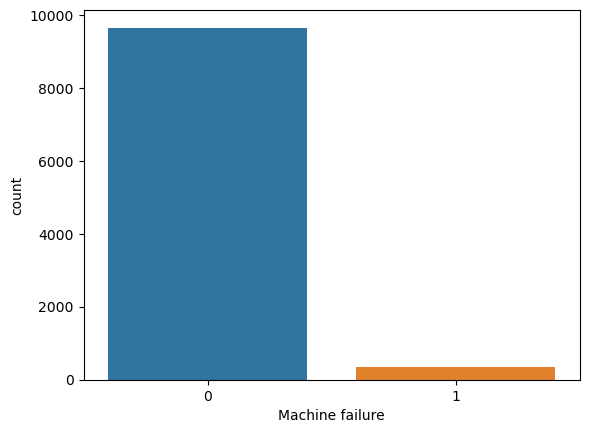

In [97]:
sns.countplot(x=data["Machine failure"])
plt.show()

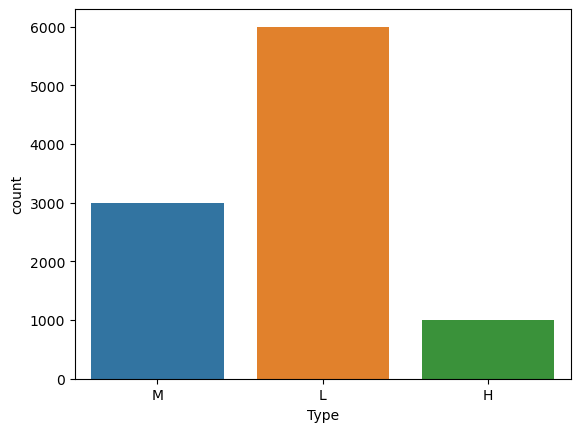

In [98]:
sns.countplot(x= data["Type"])
plt.show()

#### Histogram

array([[<Axes: title={'center': 'Air temperature'}>,
        <Axes: title={'center': 'Process temperature'}>],
       [<Axes: title={'center': 'Rotational speed'}>,
        <Axes: title={'center': 'Torque'}>],
       [<Axes: title={'center': 'Tool wear'}>, <Axes: >]], dtype=object)

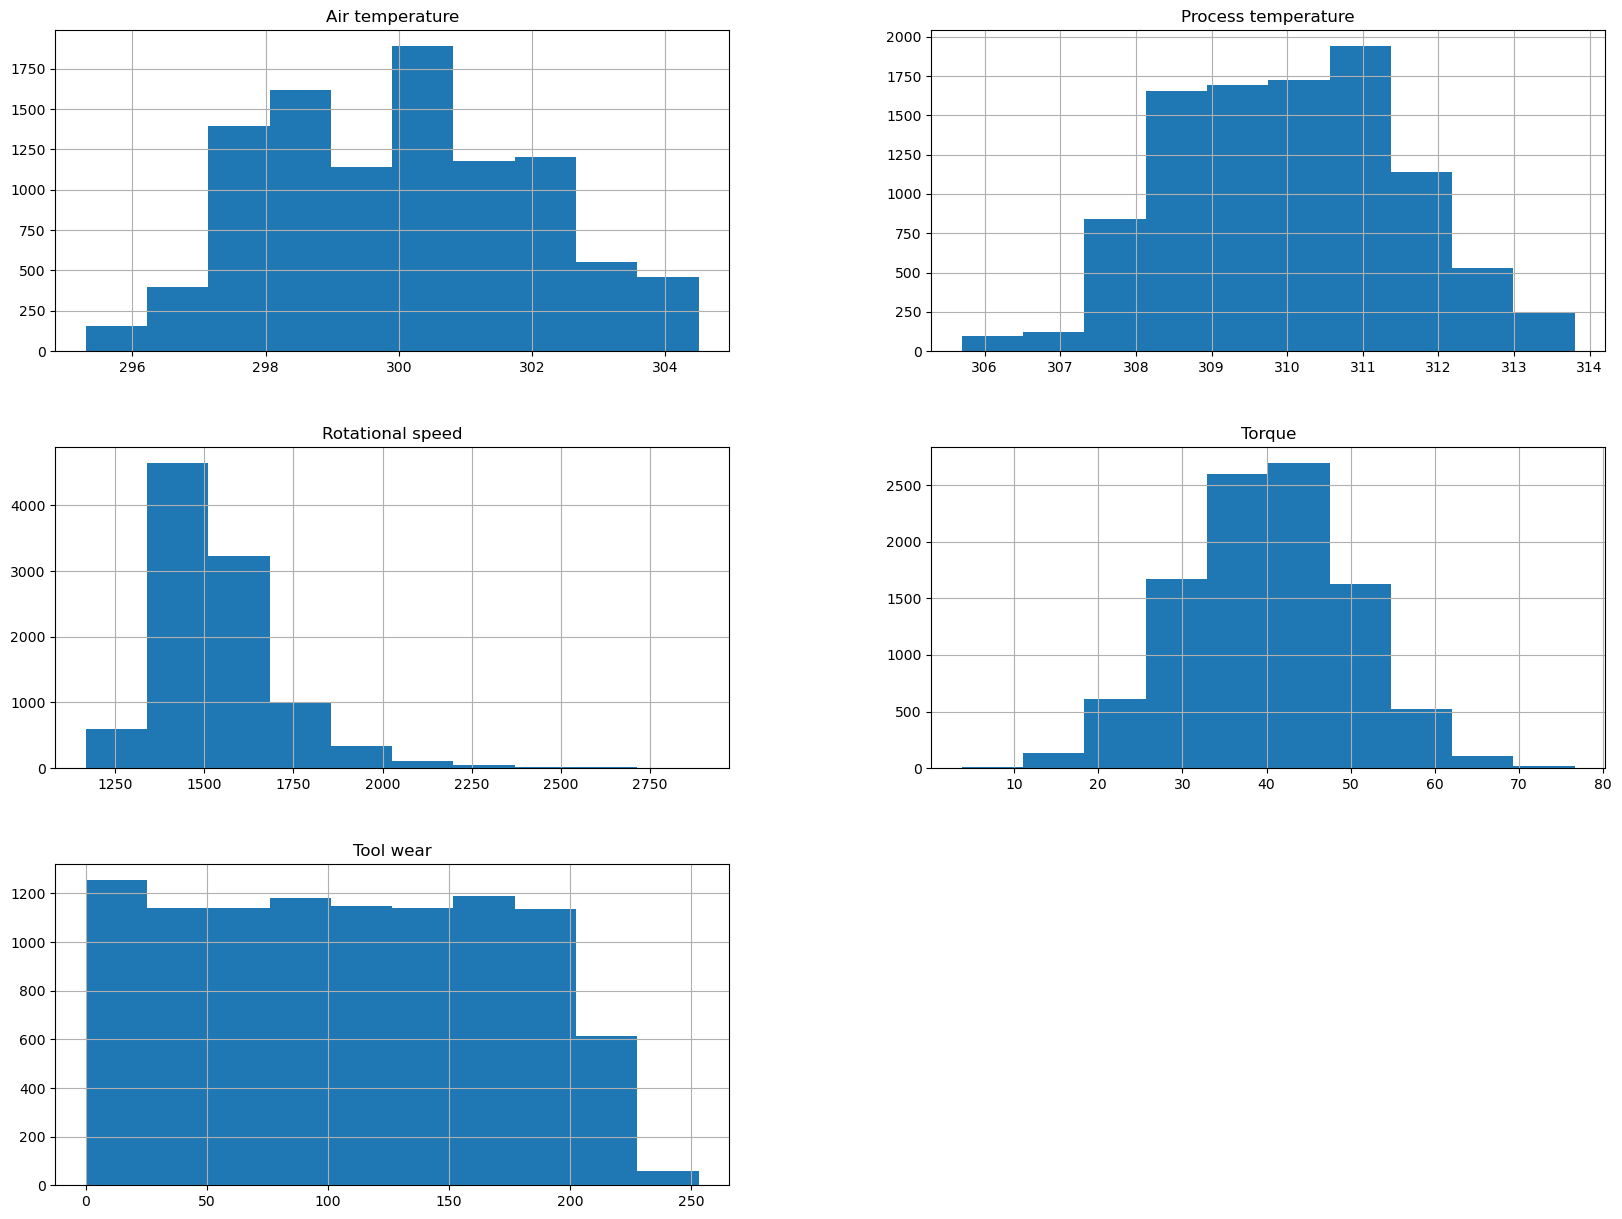

In [99]:
data[["Air temperature" ,"Process temperature","Rotational speed",
        "Torque","Tool wear"]].hist(figsize=(20, 15))

#### Boxplot for checking the outliers

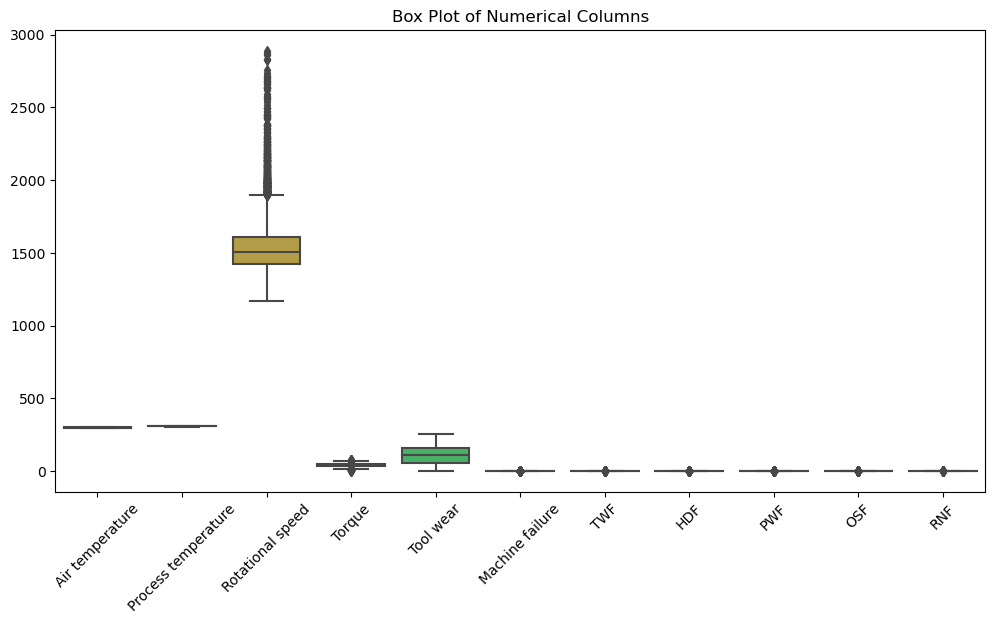

In [100]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data)
plt.title("Box Plot of Numerical Columns")
plt.xticks(rotation=45)
plt.show()

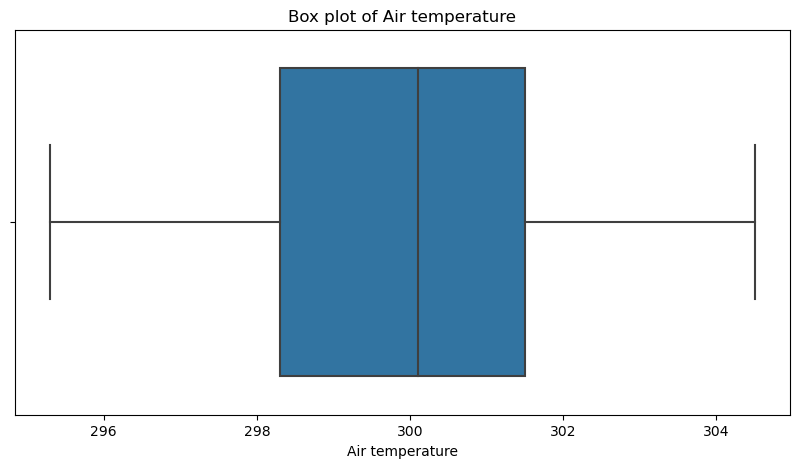

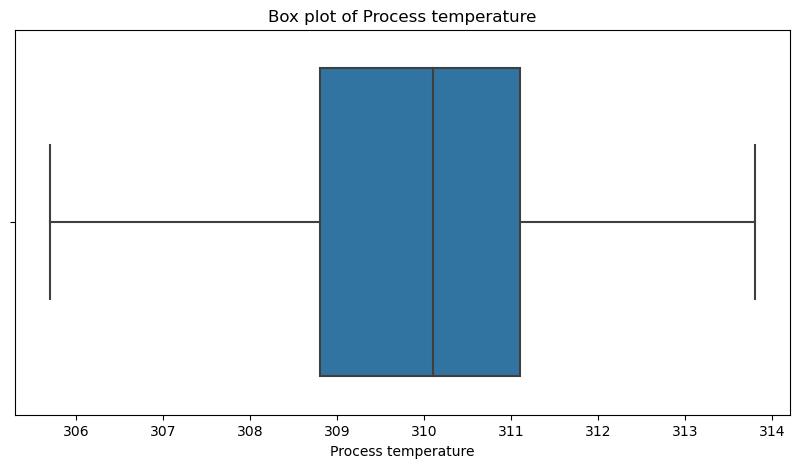

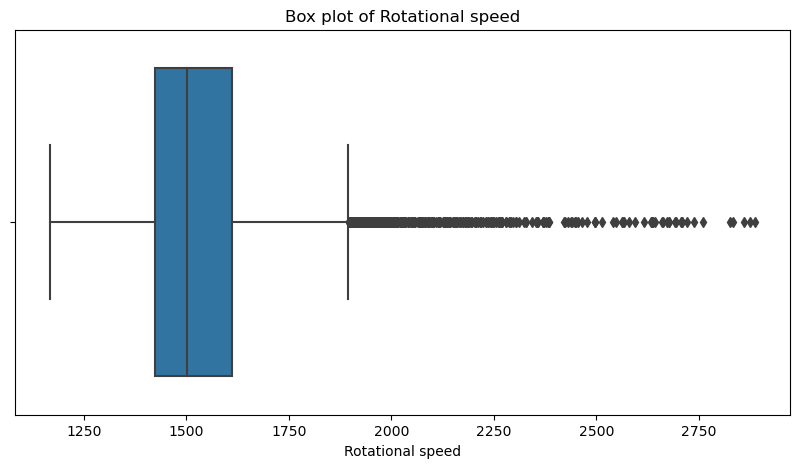

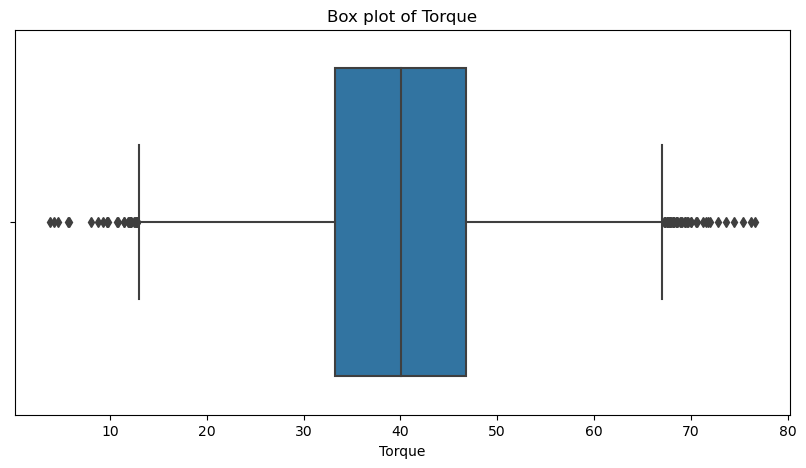

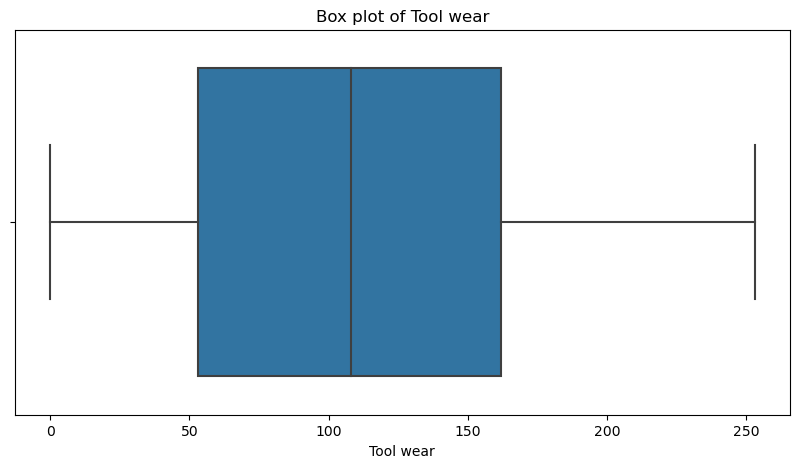

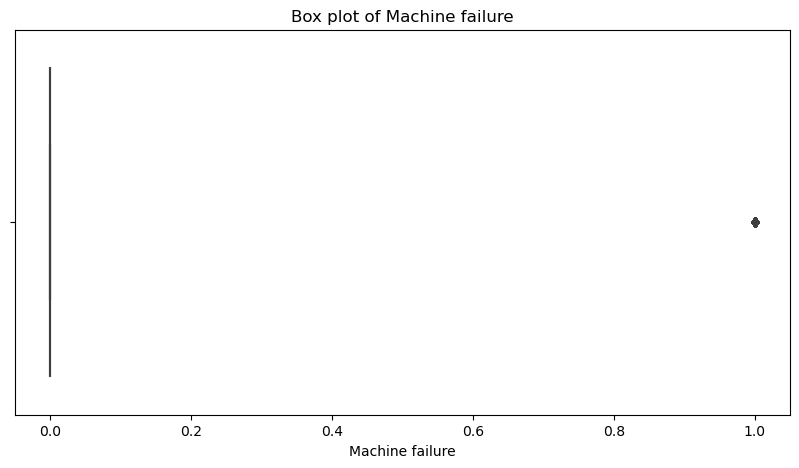

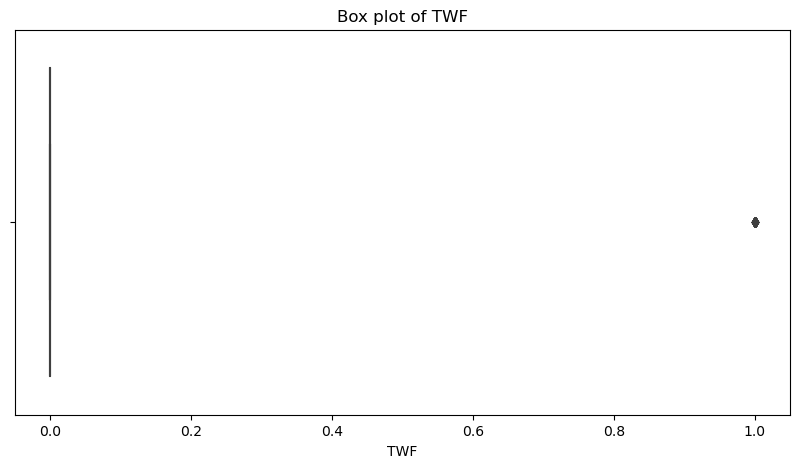

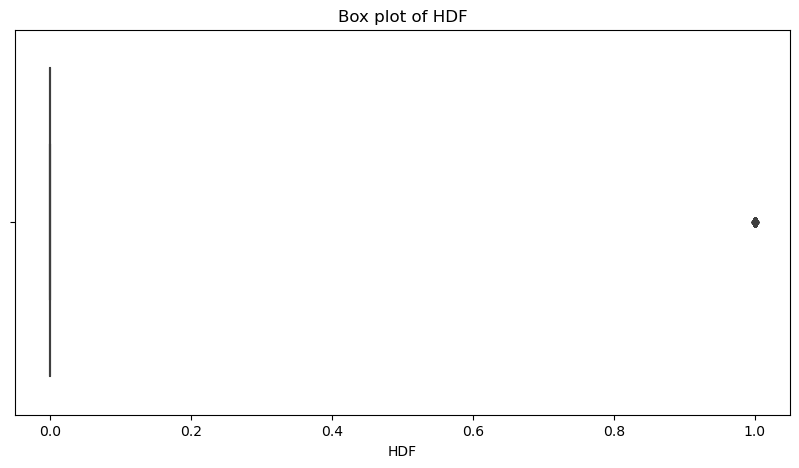

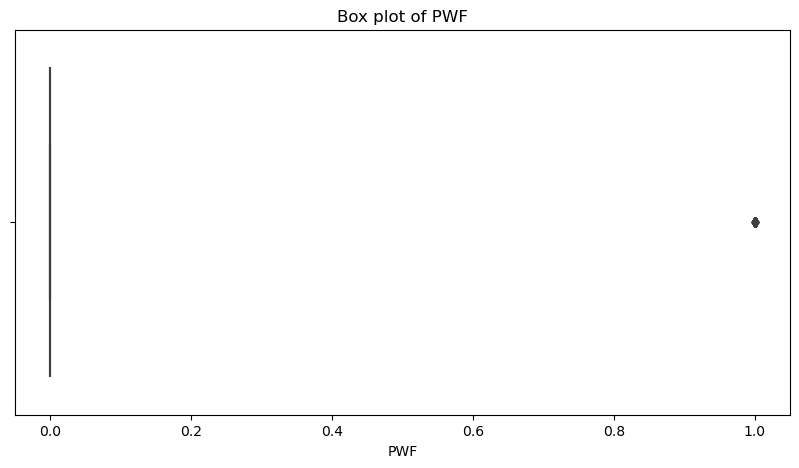

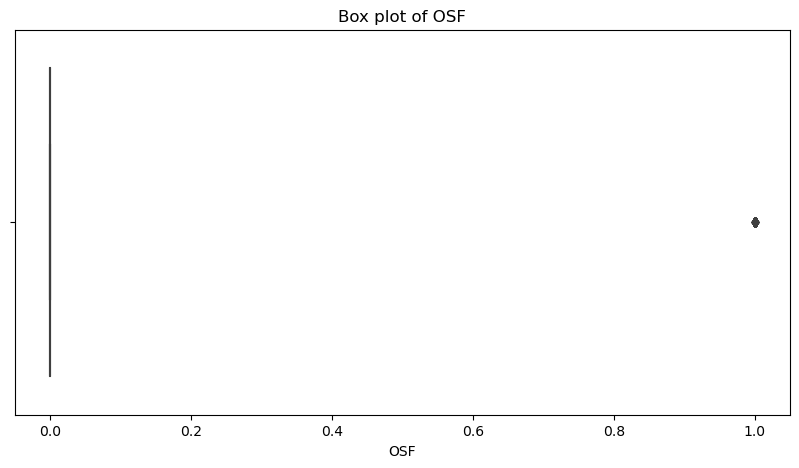

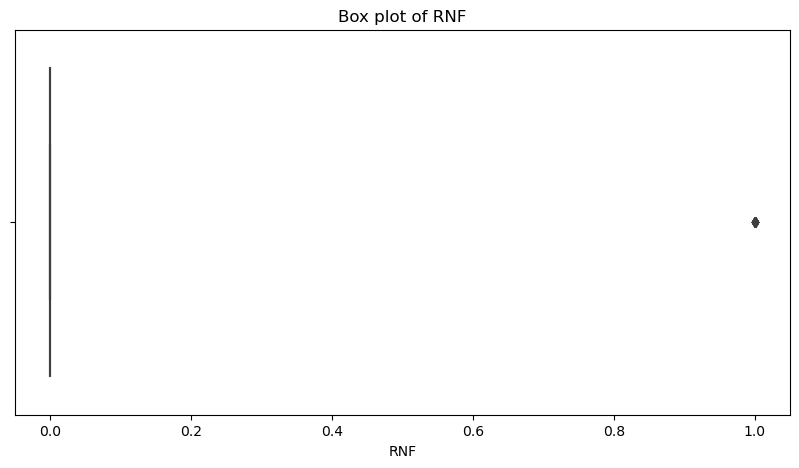

In [101]:
def plot_boxplots(data):
    for column in data.select_dtypes(include=['number']).columns:
        plt.figure(figsize=(10, 5))
        sns.boxplot(x=data[column])
        plt.title(f'Box plot of {column}')
        plt.show()

plot_boxplots(data)

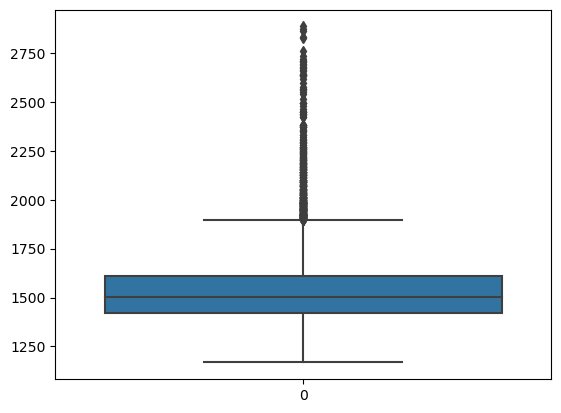

In [102]:
sns.boxplot(data=data['Rotational speed'])
plt.show()

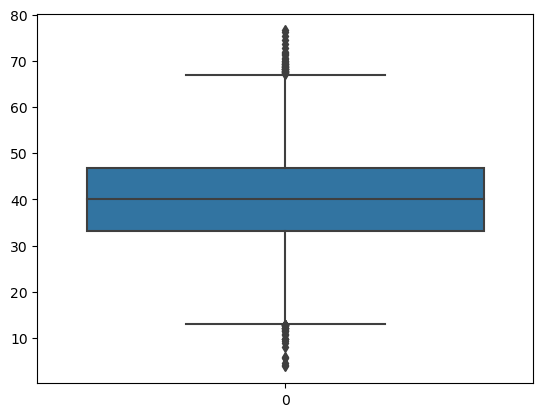

In [103]:
sns.boxplot(data=data['Torque'])
plt.show()

In [104]:
columns_to_check = ['Rotational speed', 'Torque']

In [105]:
def cap_floor_outliers(data, columns):
    for column in columns:
        Q1 = data[column].quantile(0.25)
        Q3 = data[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        data[column] = np.where(data[column] < lower_bound, lower_bound, data[column])
        data[column] = np.where(data[column] > upper_bound, upper_bound, data[column])
    return data

data_new = cap_floor_outliers(data.copy(), columns_to_check)

#### Boxplot after Outliers removed

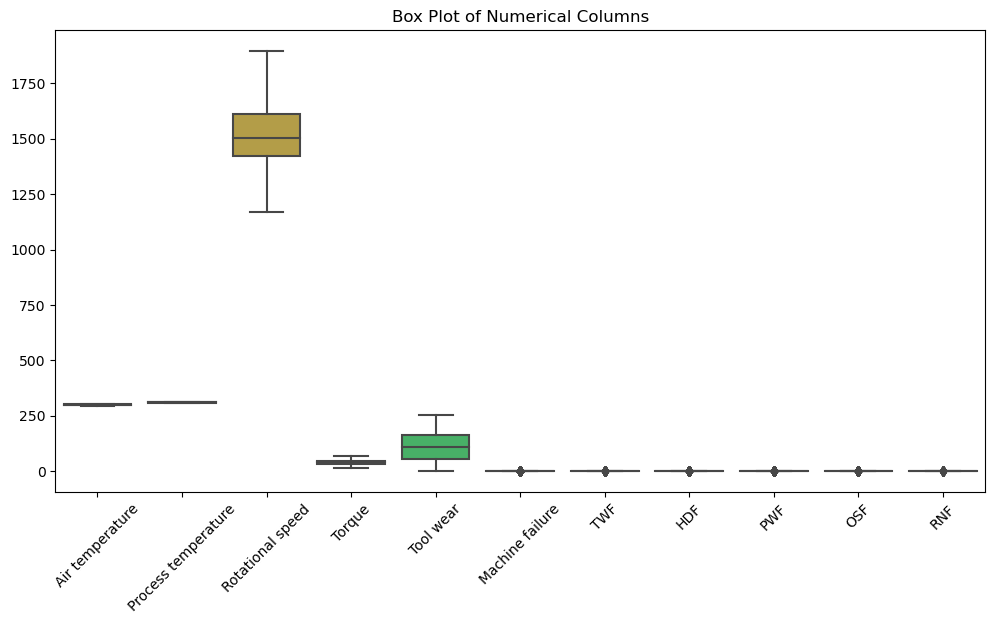

In [106]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data_new)
plt.title("Box Plot of Numerical Columns")
plt.xticks(rotation=45)
plt.show()

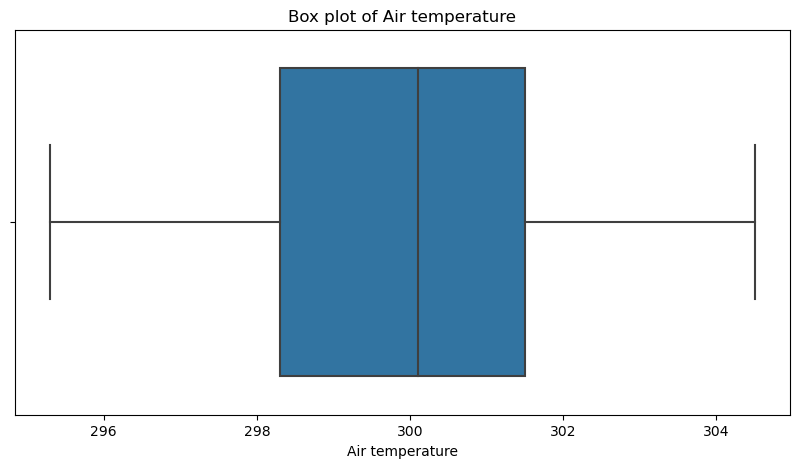

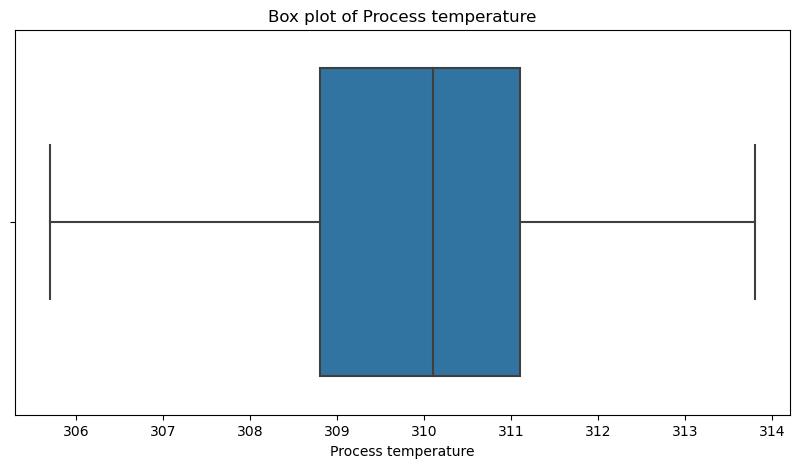

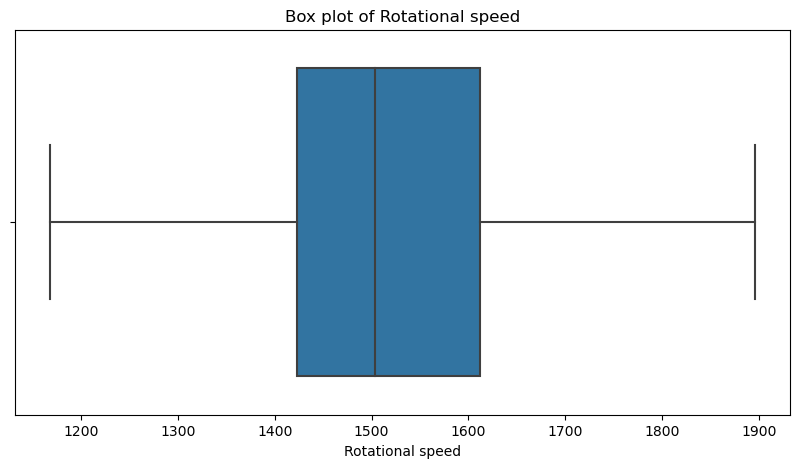

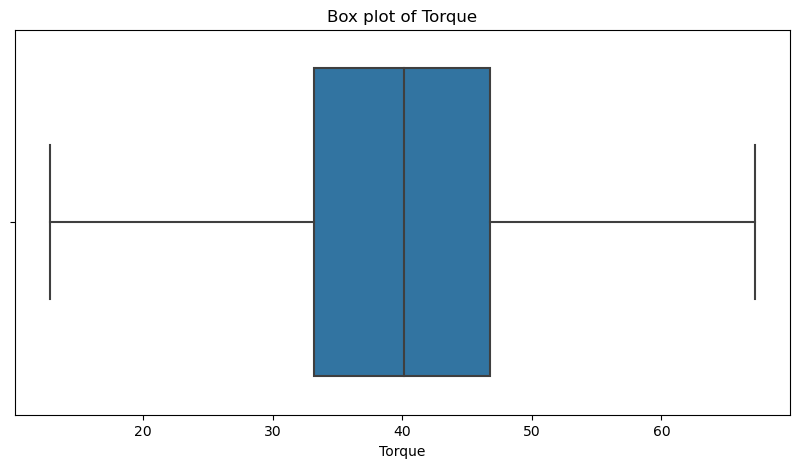

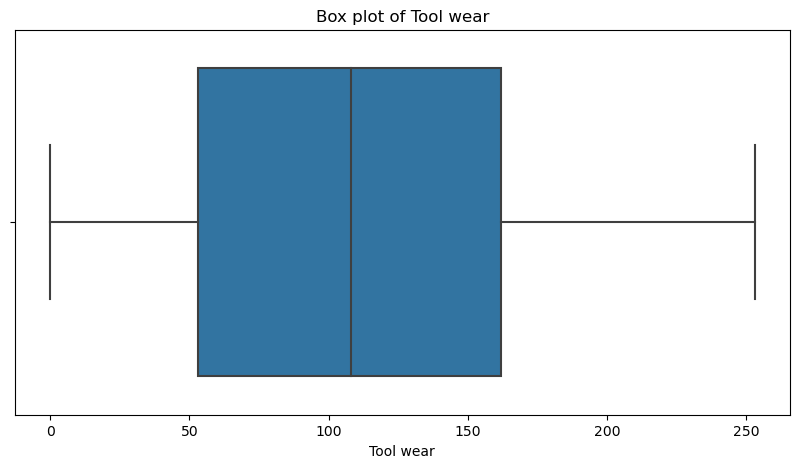

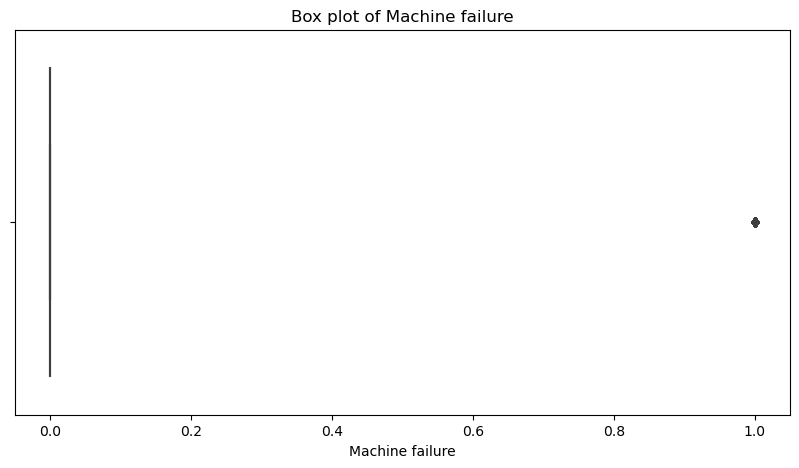

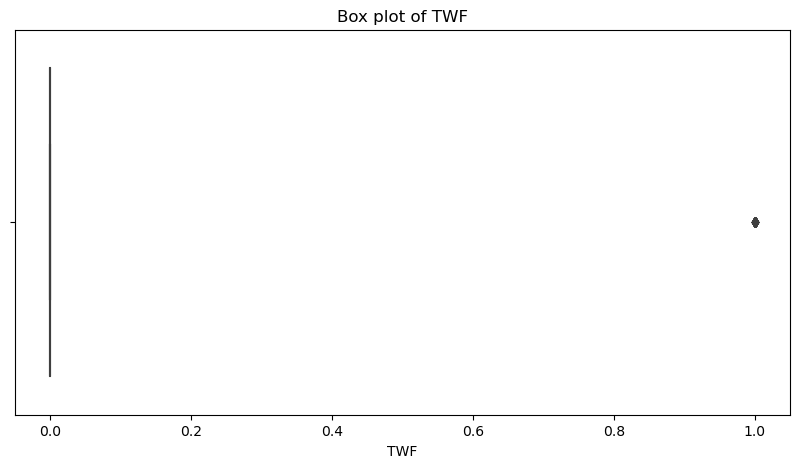

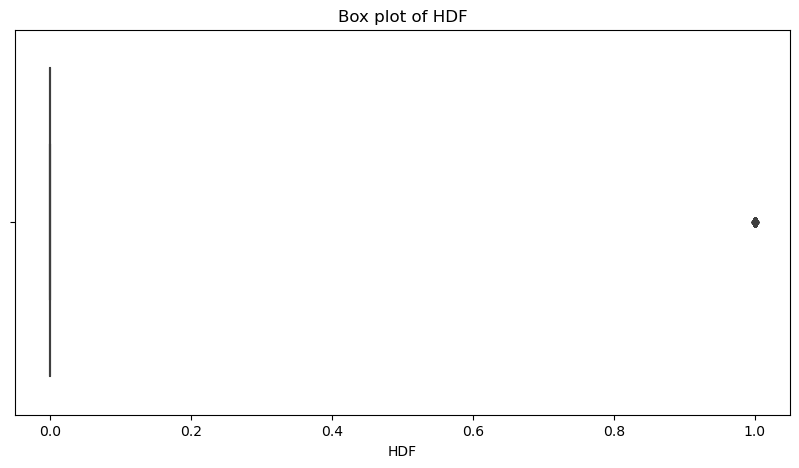

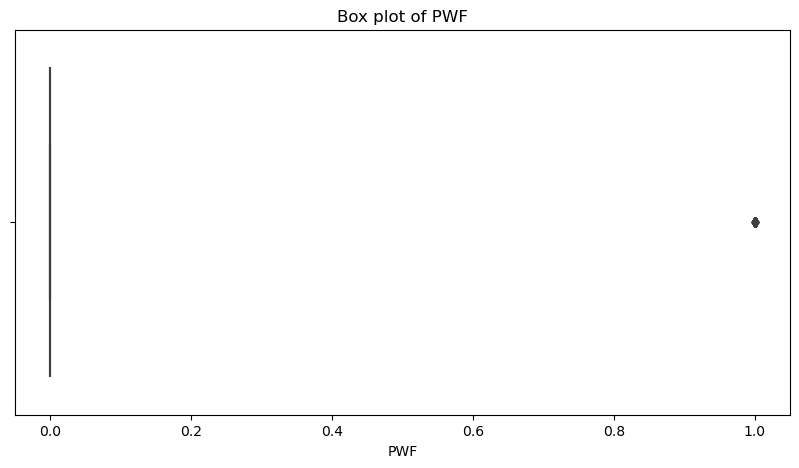

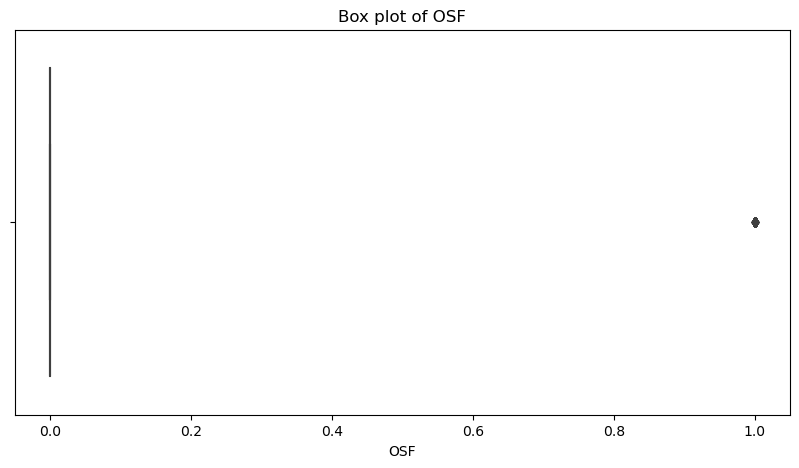

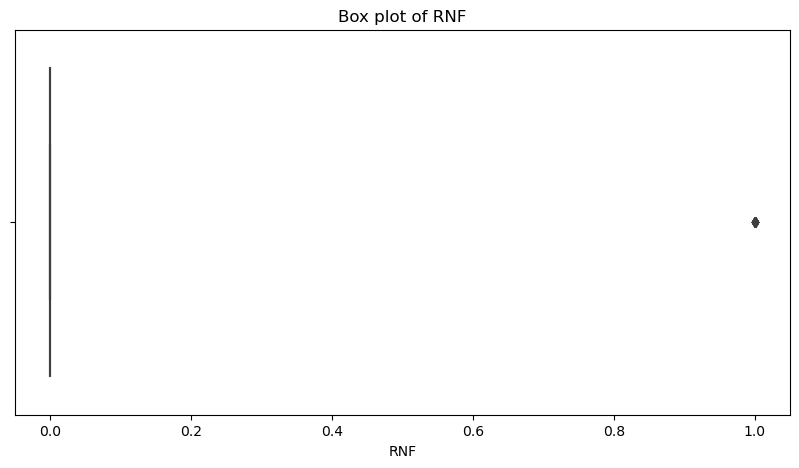

In [107]:
def plot_boxplots(data_new):
    for column in data_new.select_dtypes(include=['number']).columns:
        plt.figure(figsize=(10, 5))
        sns.boxplot(x=data_new[column])
        plt.title(f'Box plot of {column}')
        plt.show()

plot_boxplots(data_new)

#### Checking distribution by Machine Failure

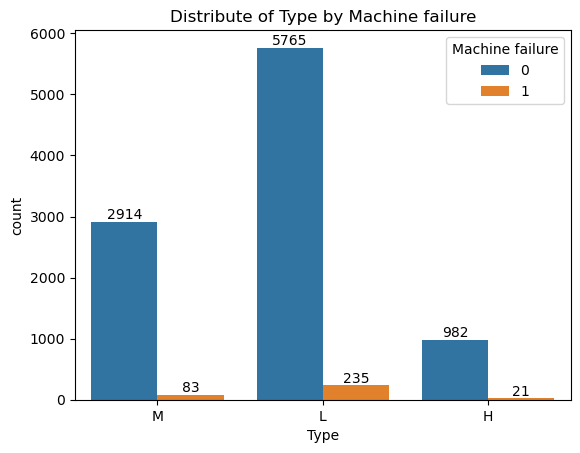

In [108]:
figure = sns.countplot(x= data_new["Type"] , hue = data_new['Machine failure'] )
for cotain in figure.containers : 
    figure.bar_label(cotain)
plt.title("Distribute of Type by Machine failure")
plt.show()

#### Pairplot for variables

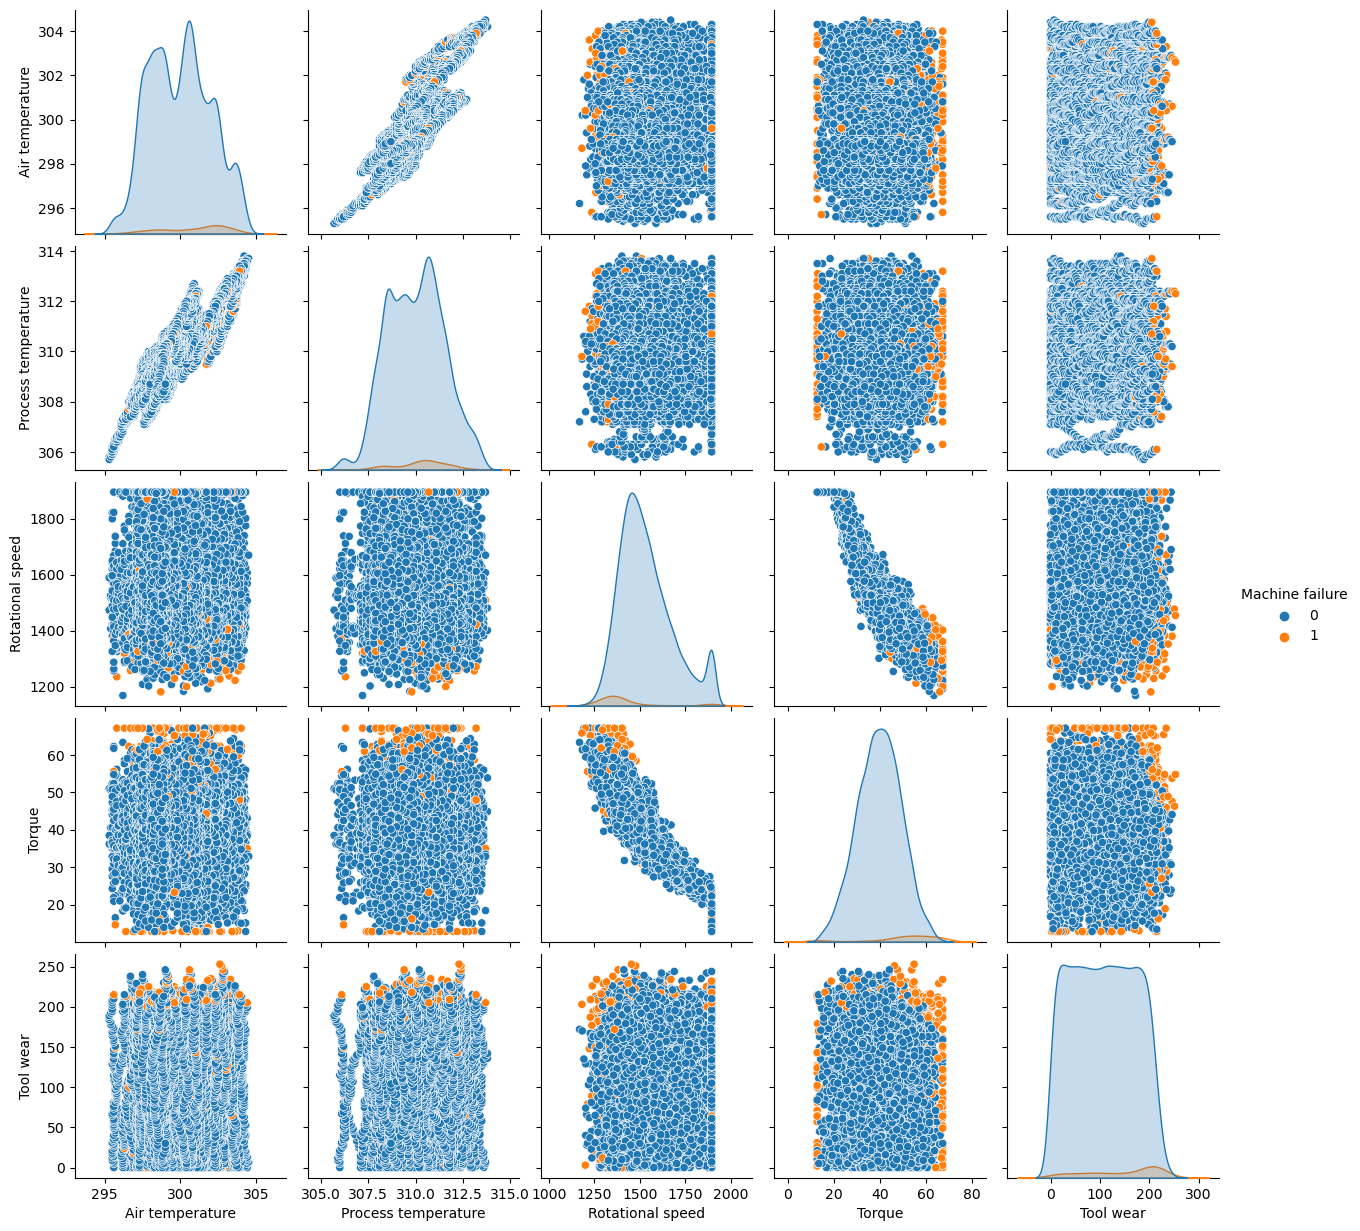

In [109]:
tt= data_new[["Air temperature" ,"Process temperature","Rotational speed",
        "Torque","Tool wear","Machine failure"]]
sns.pairplot(tt ,hue="Machine failure")

#### Correlation matrix

<Axes: >

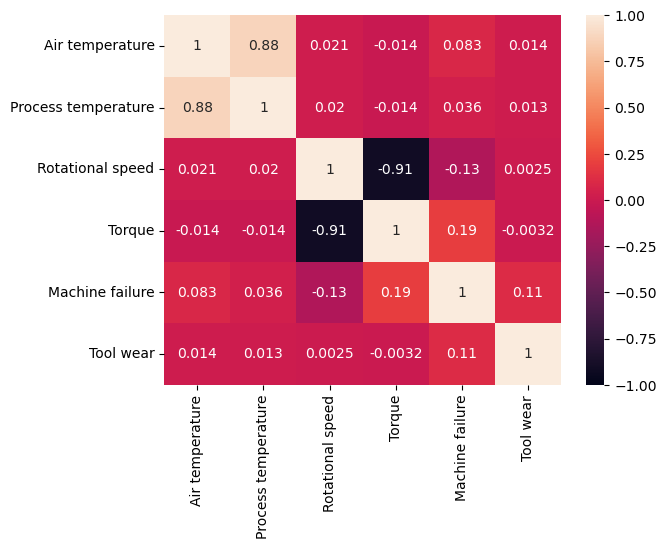

In [110]:
tt= data_new[["Air temperature" ,"Process temperature","Rotational speed",
        "Torque","Machine failure","Tool wear"]]
tt_corr = tt.corr()
sns.heatmap(tt_corr,vmin=-1 , vmax=1, annot=True)

#### Correlation matrix for each variables

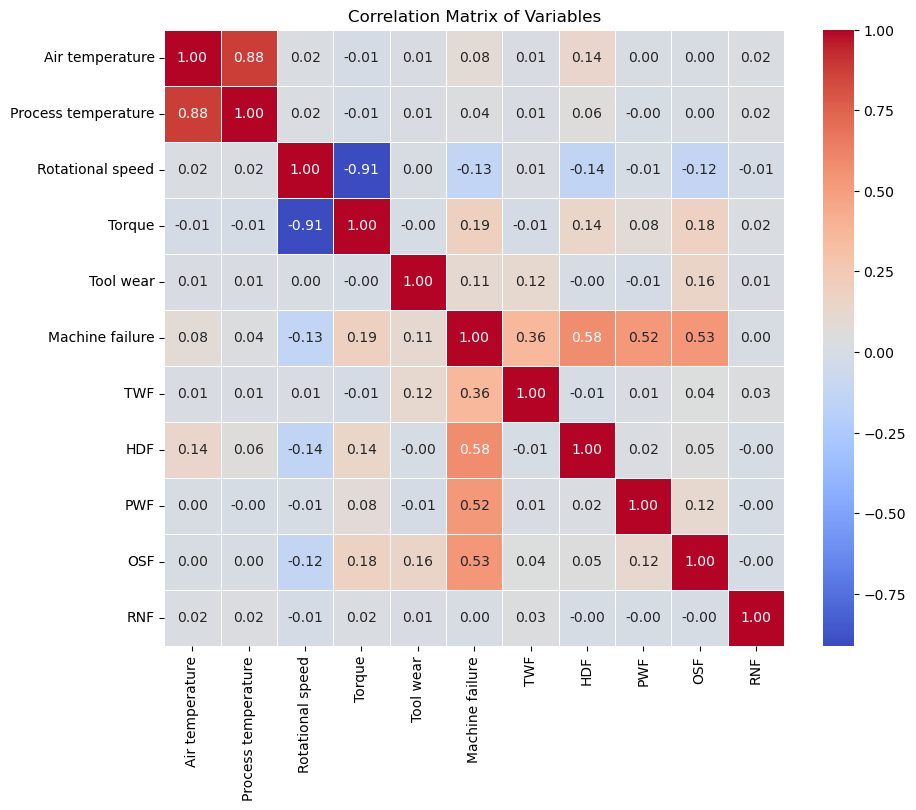

In [111]:
# Compute the correlation matrix
correlation_matrix = data_new.corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Variables')
plt.show()

In [112]:
data_new

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433.0,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,M,298.8,308.4,1604.0,29.5,14,0,0,0,0,0,0
9996,H,298.9,308.4,1632.0,31.8,17,0,0,0,0,0,0
9997,M,299.0,308.6,1645.0,33.4,22,0,0,0,0,0,0
9998,H,299.0,308.7,1408.0,48.5,25,0,0,0,0,0,0


In [113]:
data_new.describe()

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,300.004930,310.005560,1530.142500,39.983490,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2.000259,1.483734,148.798499,9.914623,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,295.300000,305.700000,1168.000000,12.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,304.500000,313.800000,1895.500000,67.200000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


### Feature Engineering

#### Data enconding using one hot encoding

In [114]:
# One-hot encode categorical variables
data_new_encoded = pd.get_dummies(data_new, columns=['Type'])
data_new_encoded

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF,Type_H,Type_L,Type_M
0,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0,0,0,1
1,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0,0,1,0
2,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0,0,1,0
3,298.2,308.6,1433.0,39.5,7,0,0,0,0,0,0,0,1,0
4,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,298.8,308.4,1604.0,29.5,14,0,0,0,0,0,0,0,0,1
9996,298.9,308.4,1632.0,31.8,17,0,0,0,0,0,0,1,0,0
9997,299.0,308.6,1645.0,33.4,22,0,0,0,0,0,0,0,0,1
9998,299.0,308.7,1408.0,48.5,25,0,0,0,0,0,0,1,0,0


#### Feature Selection 

In [115]:
X = data_new_encoded.drop(['Machine failure'], axis = 1)
y = data_new_encoded['Machine failure']

In [116]:
X

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,TWF,HDF,PWF,OSF,RNF,Type_H,Type_L,Type_M
0,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0,0,1
1,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0,1,0
2,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0,1,0
3,298.2,308.6,1433.0,39.5,7,0,0,0,0,0,0,1,0
4,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,298.8,308.4,1604.0,29.5,14,0,0,0,0,0,0,0,1
9996,298.9,308.4,1632.0,31.8,17,0,0,0,0,0,1,0,0
9997,299.0,308.6,1645.0,33.4,22,0,0,0,0,0,0,0,1
9998,299.0,308.7,1408.0,48.5,25,0,0,0,0,0,1,0,0


In [117]:
y

0       0
1       0
2       0
3       0
4       0
       ..
9995    0
9996    0
9997    0
9998    0
9999    0
Name: Machine failure, Length: 10000, dtype: int64

#### Split data into train(80%) and test(20%)

In [118]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [119]:
X_train.shape

(8000, 13)

In [120]:
X_test.shape

(2000, 13)

In [121]:
y_train.shape

(8000,)

In [122]:
y_test.shape

(2000,)

### Sampling

In [123]:
# Import the necessary libraries
from imblearn.over_sampling import SMOTE

In [124]:
# Creating an instance of SMOTE
smote = SMOTE()

# Balancing the data
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [125]:
print(y_train.value_counts())

0    7722
1     278
Name: Machine failure, dtype: int64


In [126]:
print(y_resampled.value_counts())

0    7722
1    7722
Name: Machine failure, dtype: int64


## Model Building

#### Build logicstic Regression model

In [127]:
from sklearn.linear_model import LogisticRegression

In [128]:
model = LogisticRegression()

In [129]:
model

LogisticRegression()

In [130]:
model.fit(X_resampled, y_resampled)

LogisticRegression()

In [131]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [132]:
y_pred = model.predict(X_test)

In [133]:
y_pred.shape

(2000,)

In [134]:
a = accuracy_score(y_test,y_pred)
a

0.978

In [135]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

In [136]:
# Print metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC score:", roc_auc)

Accuracy: 0.978
Precision: 0.5841584158415841
Recall: 0.9672131147540983
F1-score: 0.728395061728395
ROC-AUC score: 0.9872082110941081


#### Build Random Forest Classifier model

In [137]:
from sklearn.ensemble import RandomForestClassifier 
model2 = RandomForestClassifier(n_estimators=160 ,min_samples_leaf=50, 
                              max_depth=5,max_leaf_nodes=3 ,criterion='entropy' )

In [138]:
model2.fit(X_resampled, y_resampled)

RandomForestClassifier(criterion='entropy', max_depth=5, max_leaf_nodes=3,
                       min_samples_leaf=50, n_estimators=160)

In [139]:
y_predict_train = model2.predict(X_test)

In [140]:
b = accuracy_score(y_test,y_predict_train)
b

0.887

In [141]:
# Metrics
accuracy = accuracy_score(y_test, y_predict_train)
precision = precision_score(y_test, y_predict_train)
recall = recall_score(y_test, y_predict_train)
f1 = f1_score(y_test, y_predict_train)
roc_auc = roc_auc_score(y_test, model2.predict_proba(X_test)[:,1])

In [142]:
# Print metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC score:", roc_auc)

Accuracy: 0.887
Precision: 0.17647058823529413
Recall: 0.7377049180327869
F1-score: 0.2848101265822785
ROC-AUC score: 0.9436375011625056


#### Build XGBClassifier model

In [143]:
from xgboost import XGBClassifier

model3 = XGBClassifier(n_estimators=10 ,min_samples_leaf=60, 
                              max_depth=3,max_leaf_nodes=3 ,criterion='entropy' )

In [144]:
model3.fit(X_train.to_numpy(), y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, criterion='entropy', device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaf_nodes=3,
              max_leaves=None, min_child_weight=None, min_samples_leaf=60,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=10, ...)

In [145]:
y_predict = model3.predict(X_test)

In [146]:
c = accuracy_score(y_test,y_predict)
c

0.999

In [147]:
# Metrics
accuracy = accuracy_score(y_test, y_predict)
precision = precision_score(y_test, y_predict)
recall = recall_score(y_test, y_predict)
f1 = f1_score(y_test, y_predict)
roc_auc = roc_auc_score(y_test, model3.predict_proba(X_test)[:,1])

In [148]:
# Print metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC score:", roc_auc)

Accuracy: 0.999
Precision: 1.0
Recall: 0.9672131147540983
F1-score: 0.9833333333333333
ROC-AUC score: 0.9823806423794587


#### Build SVC model

In [149]:
from sklearn.svm import SVC 

logr = SVC(probability=True)

In [150]:
logr.fit(X_train, y_train)

SVC(probability=True)

In [151]:
y_predict_svc = logr.predict(X_test)

In [152]:
d = accuracy_score(y_test,y_predict_svc)
d

0.9695

In [153]:
# Metrics
accuracy = accuracy_score(y_test, y_predict_svc)
precision = precision_score(y_test, y_predict_svc)
recall = recall_score(y_test, y_predict_svc)
f1 = f1_score(y_test, y_predict_svc)
roc_auc = roc_auc_score(y_test, logr.predict_proba(X_test)[:,1])

In [154]:
# Print metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC score:", roc_auc)

Accuracy: 0.9695
Precision: 0.0
Recall: 0.0
F1-score: 0.0
ROC-AUC score: 0.6045282763635135


#### Build Decision Tree Classifier model

In [155]:
from sklearn.tree import DecisionTreeClassifier

model5 = DecisionTreeClassifier(min_samples_leaf=50, 
                              max_depth=10,max_leaf_nodes=1000 ,criterion='gini' )

In [156]:
model5.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, max_leaf_nodes=1000, min_samples_leaf=50)

In [157]:
y_predict_DT = model5.predict(X_test)

In [158]:
e = accuracy_score(y_test,y_predict_DT)
e

0.994

In [159]:
# Metrics
accuracy = accuracy_score(y_test, y_predict_DT)
precision = precision_score(y_test, y_predict_DT)
recall = recall_score(y_test, y_predict_DT)
f1 = f1_score(y_test, y_predict_DT)
roc_auc = roc_auc_score(y_test, model5.predict_proba(X_test)[:,1])

In [160]:
# Print metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC score:", roc_auc)

Accuracy: 0.994
Precision: 1.0
Recall: 0.8032786885245902
F1-score: 0.8909090909090909
ROC-AUC score: 0.9438869114551187


#### Create dataframe with accuracy results for all models

In [161]:
accuracyy = np.array([[a,'LogisticRegression'],
                      [b,'RandomForestClassifier'],
                      [c,'XGBClassifier'],
                      [d,'SVC classifier'],
                      [e,'DecisionTreeClassifier']])

In [162]:
column_names = ['Accuracy', 'Model']

In [163]:
df = pd.DataFrame(accuracyy, columns=column_names)

In [164]:
df

,Accuracy,Model
0,0.978,LogisticRegression
1,0.887,RandomForestClassifier
2,0.999,XGBClassifier
3,0.9695,SVC classifier
4,0.994,DecisionTreeClassifier


#### Classification reports for each model

In [165]:
from sklearn.metrics import classification_report, confusion_matrix

In [166]:
print("Logistic Regression Model report: \n\n", classification_report(y_test, y_pred))

Logistic Regression Model report: 

               precision    recall  f1-score   support

           0       1.00      0.98      0.99      1939
           1       0.58      0.97      0.73        61

    accuracy                           0.98      2000
   macro avg       0.79      0.97      0.86      2000
weighted avg       0.99      0.98      0.98      2000



In [167]:
print("Random Forest Classifier Model report: \n\n", classification_report(y_test, y_predict_train))

Random Forest Classifier Model report: 

               precision    recall  f1-score   support

           0       0.99      0.89      0.94      1939
           1       0.18      0.74      0.28        61

    accuracy                           0.89      2000
   macro avg       0.58      0.81      0.61      2000
weighted avg       0.97      0.89      0.92      2000



In [168]:
print("XGBClassifier Model report: \n\n", classification_report(y_test, y_predict))

XGBClassifier Model report: 

               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1939
           1       1.00      0.97      0.98        61

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [169]:
print("SVC classifier Model report: \n\n", classification_report(y_test, y_predict_svc))

SVC classifier Model report: 

               precision    recall  f1-score   support

           0       0.97      1.00      0.98      1939
           1       0.00      0.00      0.00        61

    accuracy                           0.97      2000
   macro avg       0.48      0.50      0.49      2000
weighted avg       0.94      0.97      0.95      2000



In [170]:
print("Decision Tree Classifier Model report: \n\n", classification_report(y_test, y_predict_DT))

Decision Tree Classifier Model report: 

               precision    recall  f1-score   support

           0       0.99      1.00      1.00      1939
           1       1.00      0.80      0.89        61

    accuracy                           0.99      2000
   macro avg       1.00      0.90      0.94      2000
weighted avg       0.99      0.99      0.99      2000



### We are selecting Logicstic regression model as our final model

# Now Moving On To Model Deployment Using  Spyder